<a href="https://colab.research.google.com/github/epleywin/ECON3916-Statistical-Machine-Learning/blob/main/Project%201/%20Phase_2_Epley_Win.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resume Callback Analysis

This notebook explores a dataset of resumes that were submitted to job
advertisements as part of a research experiment. The goal is to explore
whether different resume characteristics are associated with receiving
a callback from employers.

The dataset contains information about the job posting, the applicant,
and several features of the resume.

## Research Question

The main question explored in this analysis is whether certain resume
characteristics influence the probability that an applicant receives a
callback from an employer.

The dataset includes several variables describing the job posting,
applicant background, and resume features. By examining these variables
we can begin to understand which factors may be related to employer
responses.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

## Dataset Structure

Each row in the dataset represents a resume that was submitted in
response to a job advertisement. The dataset contains 4870 resumes.

The dataset includes three main types of information.

Job advertisement characteristics
Applicant background information
Resume features that might influence hiring decisions

The variable received_callback indicates whether the applicant
received a response from the employer.

In [ ]:
df = pd.read_csv("resume.csv")
df.head()

,job_ad_id,job_city,job_industry,job_type,job_fed_contractor,job_equal_opp_employer,job_ownership,job_req_any,job_req_communication,job_req_education,...,honors,worked_during_school,years_experience,computer_skills,special_skills,volunteer,military,employment_holes,has_email_address,resume_quality
0,384,Chicago,manufacturing,supervisor,NaN,1,unknown,1,0,0,...,0,0,6,1,0,0,0,1,0,low
1,384,Chicago,manufacturing,supervisor,NaN,1,unknown,1,0,0,...,0,1,6,1,0,1,1,0,1,high
2,384,Chicago,manufacturing,supervisor,NaN,1,unknown,1,0,0,...,0,1,6,1,0,0,0,0,0,low
3,384,Chicago,manufacturing,supervisor,NaN,1,unknown,1,0,0,...,0,0,6,1,1,1,0,1,1,high
4,385,Chicago,other_service,secretary,0.0,1,nonprofit,1,0,0,...,0,1,22,1,0,0,0,0,1,high


## Dataset Size

The dataset contains 4870 resume submissions and 30 variables. Each row
represents a single resume that was sent in response to a job
advertisement. The variables include information about the job posting,
the applicant, and several features of the resume.

Because the dataset contains a large number of resumes it provides a
useful opportunity to explore patterns in employer callback behavior.

In [ ]:
df.shape

(4870, 30)

## Dataset Information

The dataset contains a mixture of numeric and categorical variables.
Numeric variables include measures such as years of experience and
binary indicators that represent whether a resume includes certain
features.

Categorical variables include information such as the applicant's race,
gender, job industry, and resume quality. These variables help describe
the context of each resume submission and will be useful for comparing
callback outcomes across different groups.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_ad_id               4870 non-null   int64  
 1   job_city                4870 non-null   object 
 2   job_industry            4870 non-null   object 
 3   job_type                4870 non-null   object 
 4   job_fed_contractor      3102 non-null   float64
 5   job_equal_opp_employer  4870 non-null   int64  
 6   job_ownership           4870 non-null   object 
 7   job_req_any             4870 non-null   int64  
 8   job_req_communication   4870 non-null   int64  
 9   job_req_education       4870 non-null   int64  
 10  job_req_min_experience  2124 non-null   object 
 11  job_req_computer        4870 non-null   int64  
 12  job_req_organization    4870 non-null   int64  
 13  job_req_school          4870 non-null   object 
 14  received_callback       4870 non-null   

## Column Descriptions

The dataset contains several groups of variables.

Job related variables describe the job advertisement itself. These
include job_ad_id, job_city, job_industry, job_type, and information
about job requirements such as communication skills, education, and
computer skills.

Applicant characteristics describe the person listed on the resume.
These include the applicant's first name, race, gender, years of
college education, and years of work experience.

Resume features describe additional qualities of the applicant. These
include whether the applicant graduated from college, received honors,
worked during school, had volunteer experience, military experience,
or employment gaps.

The variable received_callback indicates whether the employer contacted
the applicant after receiving the resume. A value of 1 indicates a
callback and 0 indicates no response.

In [ ]:
df.describe()

,job_ad_id,job_fed_contractor,job_equal_opp_employer,job_req_any,job_req_communication,job_req_education,job_req_computer,job_req_organization,received_callback,years_college,college_degree,honors,worked_during_school,years_experience,computer_skills,special_skills,volunteer,military,employment_holes,has_email_address
count,4870.000000,3102.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000
mean,651.777823,0.114765,0.291170,0.787269,0.124846,0.106776,0.437166,0.072690,0.080493,3.618480,0.719507,0.052772,0.559548,7.842916,0.820534,0.328747,0.411499,0.097125,0.448049,0.479261
std,388.690698,0.318789,0.454349,0.409281,0.330578,0.308860,0.496087,0.259654,0.272083,0.714997,0.449286,0.223601,0.496492,5.044612,0.383782,0.469806,0.492156,0.296159,0.497345,0.499621
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,306.250000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,647.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,6.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,979.750000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,9.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,1344.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000,44.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Summary Statistics

The summary statistics provide an overview of several numeric variables
in the dataset. Many of the variables represent binary indicators where
a value of 1 means the feature is present and 0 means it is not.

For example, variables such as college_degree, honors, volunteer, and
military indicate whether the applicant listed those experiences on the
resume. The mean values for these variables show the proportion of
resumes that include each feature.

The average years_experience in the dataset is about 7.84 years. The median number of years of college education is four years, suggesting that many applicants in the dataset completed a typical undergraduate education.

These statistics provide a general overview of the characteristics of
the resumes included in the study.

## Missing Data

Most variables in the dataset contain complete information for all
4870 resumes. However, some variables contain missing values.

The variable job_fed_contractor contains missing values because not
every job advertisement specified whether the employer was a federal
contractor. The variable job_req_min_experience also has missing values
because some job postings did not list a minimum experience
requirement.

These missing values should be considered when performing deeper
analysis later in the project.

In [ ]:
df.isnull().sum()

,0
job_ad_id,0
job_city,0
job_industry,0
job_type,0
job_fed_contractor,1768
job_equal_opp_employer,0
job_ownership,0
job_req_any,0
job_req_communication,0
job_req_education,0


## Callback Outcomes

The variable received_callback indicates whether the employer contacted
the applicant after receiving the resume.

Out of the 4870 resumes in the dataset, 392 received a callback while
4478 did not receive a response. This means that only a small portion of
applicants received follow up contact from employers.

Because callbacks are relatively rare, it will be interesting to explore
whether certain resume characteristics are associated with a higher
probability of receiving a response.

In [ ]:
df["received_callback"].value_counts()

,count
received_callback,
0,4478
1,392


## Race Distribution

The dataset contains an equal number of resumes associated with white
and black applicants. Each group contains 2435 resumes.

This balanced design allows researchers to compare callback rates
between the two groups while keeping the number of resumes the same.
Because the groups are evenly represented, differences in callback
rates are easier to interpret.

In [ ]:
df["race"].value_counts()

,count
race,
white,2435
black,2435


## Gender Distribution

The dataset includes both male and female applicants. There are 3746
female applicants and 1124 male applicants in the dataset.

This means that a larger share of the resumes represent female
applicants. Gender may also play a role in employer responses, so it
may be useful to explore this variable further in later analysis.

In [ ]:
df["gender"].value_counts()

,count
gender,
f,3746
m,1124


## Resume Quality

The dataset also includes a variable that describes the overall quality
of the resume. There are 2446 resumes classified as high quality and
2424 classified as low quality.

Because the number of high and low quality resumes is nearly equal,
this variable may help reveal whether stronger resumes are more likely
to receive callbacks from employers.

In [ ]:
df["resume_quality"].value_counts()

,count
resume_quality,
high,2446
low,2424


## Outlier Detection

Outliers were identified using the Tukey Fence method based on the
interquartile range. This approach flags observations that fall far
outside the typical range of the data.

The analysis was applied to the years_experience variable to detect
extreme values that may influence the results of later statistical
analysis.

In [ ]:
Q1 = df["years_experience"].quantile(0.25)
Q3 = df["years_experience"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["years_experience"] < lower_bound) | (df["years_experience"] > upper_bound)]

print("Number of potential outliers:", len(outliers))

Number of potential outliers: 431


## Visual Exploration

To better understand the relationships in the dataset, several
visualizations are created below. These graphs help illustrate patterns
between applicant characteristics and employer callback outcomes.

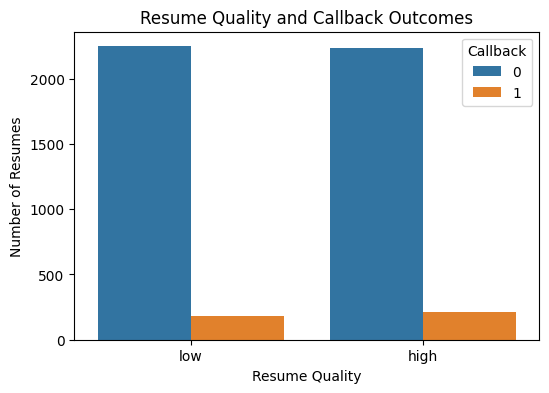

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="resume_quality", hue="received_callback", data=df)

plt.title("Resume Quality and Callback Outcomes")
plt.xlabel("Resume Quality")
plt.ylabel("Number of Resumes")

plt.legend(title="Callback")

plt.show()

This graph compares callback outcomes between high quality and low
quality resumes. It allows us to observe whether resumes classified as
higher quality appear to receive more responses from employers.

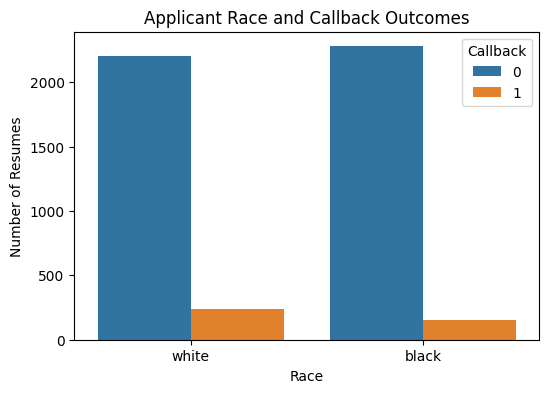

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="race", hue="received_callback", data=df)

plt.title("Applicant Race and Callback Outcomes")
plt.xlabel("Race")
plt.ylabel("Number of Resumes")

plt.legend(title="Callback")

plt.show()

This visualization compares callback outcomes across racial groups in
the dataset. Because the dataset contains equal numbers of resumes for
each group, differences in callback counts may indicate differences in
employer responses.

## Univariate Distribution of the Dependent Variable

The dependent variable in this dataset is received_callback, which indicates whether an employer contacted the applicant after receiving the resume. This variable is binary, meaning it only takes two possible values: 0 (no callback) and 1 (callback received).

In many economic datasets, the dependent variable is continuous, such as wages or income. In those cases, it is common to visualize the distribution using histograms and apply a log transformation to reduce right skewness. However, this approach is not appropriate for the current dataset because the outcome variable is binary rather than continuous.

Because the variable only contains two possible values, a histogram or log transformation would not provide meaningful information about the distribution. Instead, the most useful way to visualize the outcome variable is to display the number of resumes that received callbacks compared to those that did not. This allows us to clearly see how rare callbacks are within the dataset.

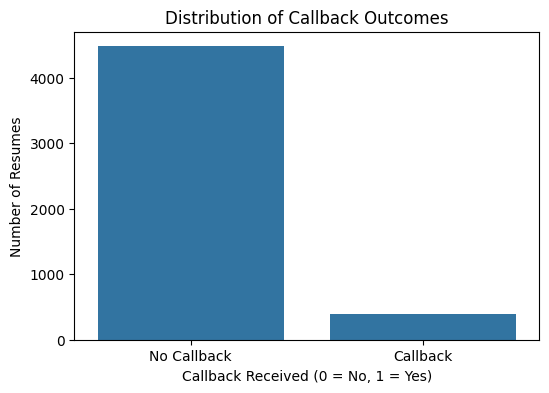

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="received_callback", data=df)

plt.title("Distribution of Callback Outcomes")
plt.xlabel("Callback Received (0 = No, 1 = Yes)")
plt.ylabel("Number of Resumes")

plt.xticks([0,1], ["No Callback", "Callback"])

plt.show()

## Bivariate Relationship Between Race and Callback Outcomes

Our next step is to examine the relationship between a key independent variable and the outcome variable. In this dataset, one important variable is race, which identifies whether the resume was associated with a white or black applicant.

For many datasets, relationships between variables are explored using scatter plots or box plots. Scatter plots are useful when both variables are continuous, while box plots help compare distributions across groups. However, because the outcome variable received_callback is binary, a box plot does not provide much meaningful variation. Most observations take the value of zero, which causes the box plot to collapse near the bottom of the graph and makes it difficult to interpret differences between groups.

Instead, a more informative approach is to examine the callback rate for each group. By calculating the proportion of resumes that received callbacks within each racial group, we can directly compare the likelihood of employer responses. This type of visualization provides a clearer “eyeball test” for identifying potential differences in callback outcomes across groups.

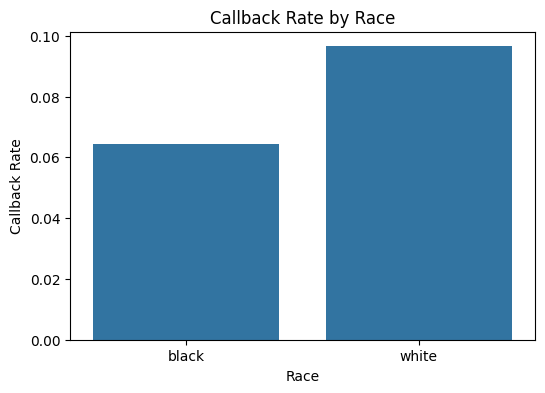

In [ ]:
callback_rate = df.groupby("race")["received_callback"].mean().reset_index()

plt.figure(figsize=(6,4))

sns.barplot(x="race", y="received_callback", data=callback_rate)

plt.title("Callback Rate by Race")
plt.xlabel("Race")
plt.ylabel("Callback Rate")

plt.show()

## Initial Observations

The dataset contains a large number of resumes submitted to job
advertisements across different industries and locations. The
information included in the dataset describes both the characteristics
of the job postings and the qualifications listed on each resume.

Initial exploration shows that only a small percentage of applicants
received callbacks from employers. Out of 4870 resumes only 392
received a response, which suggests that employer callbacks are
relatively rare events.

The dataset also includes balanced groups for race and resume quality.
Because the number of resumes in each group is similar it allows for
more reliable comparisons between applicants.

These early observations suggest that variables such as resume quality,
experience, and applicant characteristics may influence the probability
of receiving a callback.

The visualizations also highlight differences in callback outcomes
across several variables, including resume quality and applicant race.
These patterns suggest that certain resume characteristics may be
associated with differences in employer responses.

## Conclusion

This notebook explored the structure and basic characteristics of the
resume callback dataset. The dataset contains 4870 resumes and includes
variables describing job postings, applicant backgrounds, and resume
features.

The initial analysis examined summary statistics, missing data, and the
distribution of key variables such as callbacks, race, gender, and
resume quality. These results provide a foundation for deeper analysis
in later stages of the project.

Future analysis can focus on identifying which resume characteristics
are most strongly associated with receiving a callback from employers.